# Part D - Q5: Object Detection with Faster R-CNN

**Task:** Fine-tune a pretrained **Faster R-CNN** model for object detection on the first
100 training images (**10 epochs**). On the 28 test images, report **precision and recall
for each class** (except background) with an **IoU threshold of 0.5**.

**Dataset:** 128 images with Pascal-VOC XML annotations. Object names in the XML are
`obj1..obj4`, which correspond to the 4 product classes:
`obj1 -> Water Bottle`, `obj2 -> Milk Bottle`, `obj3 -> Tetra Pack`, `obj4 -> Can`.

In [1]:
import os, glob, random, numpy as np, torch
import xml.etree.ElementTree as ET
from PIL import Image
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as TF
from collections import defaultdict

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

ROOT = os.path.join("data", "detection", "dataset2")
IMG_DIR, ANN_DIR = os.path.join(ROOT, "images"), os.path.join(ROOT, "annotations")

# label 0 is reserved for background in torchvision detection models
RAW2NAME = {"obj1": "Water Bottle", "obj2": "Milk Bottle", "obj3": "Tetra Pack", "obj4": "Can"}
RAW2LABEL = {"obj1": 1, "obj2": 2, "obj3": 3, "obj4": 4}
LABEL2NAME = {1: "Water Bottle", 2: "Milk Bottle", 3: "Tetra Pack", 4: "Can"}
NUM_CLASSES = 5  # 4 objects + background

Using device: cuda


## Split: first 100 images for train, remaining 28 for test (by numeric filename)

In [2]:
all_ids = sorted([int(os.path.splitext(os.path.basename(p))[0]) for p in glob.glob(os.path.join(IMG_DIR, "*.jpg"))])
train_ids = all_ids[:100]
test_ids = all_ids[100:]
print(f"Total images: {len(all_ids)}  |  Train: {len(train_ids)}  |  Test: {len(test_ids)}")

def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    boxes, labels = [], []
    for obj in tree.findall("object"):
        name = obj.find("name").text.strip()
        if name not in RAW2LABEL:
            continue
        b = obj.find("bndbox")
        xmin, ymin = float(b.find("xmin").text), float(b.find("ymin").text)
        xmax, ymax = float(b.find("xmax").text), float(b.find("ymax").text)
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(RAW2LABEL[name])
    return boxes, labels

class DetDataset(torch.utils.data.Dataset):
    def __init__(self, ids, train=False):
        self.ids, self.train = ids, train
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, i):
        img_id = self.ids[i]
        img = Image.open(os.path.join(IMG_DIR, f"{img_id}.jpg")).convert("RGB")
        boxes, labels = parse_xml(os.path.join(ANN_DIR, f"{img_id}.xml"))
        if self.train and random.random() < 0.5:
            w = img.width
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            boxes = [[w - x2, y1, w - x1, y2] for x1, y1, x2, y2 in boxes]
        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([img_id]),
        }
        return TF.to_tensor(img), target

def collate(batch):
    return tuple(zip(*batch))

train_loader = torch.utils.data.DataLoader(DetDataset(train_ids, True), batch_size=2, shuffle=True, num_workers=0, collate_fn=collate)
test_loader = torch.utils.data.DataLoader(DetDataset(test_ids, False), batch_size=1, shuffle=False, num_workers=0, collate_fn=collate)

Total images: 128  |  Train: 100  |  Test: 28


## Load pretrained Faster R-CNN (ResNet-50 FPN) and replace the head for 5 classes

In [3]:
model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model = model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=5e-4)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\sudwivedi/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


  0%|          | 0.00/160M [00:00<?, ?B/s]

  0%|          | 128k/160M [00:00<20:13, 138kB/s]

  0%|          | 256k/160M [00:01<14:41, 190kB/s]

  0%|          | 384k/160M [00:01<11:33, 241kB/s]

...

 91%|█████████ | 145M/160M [00:16<00:00, 30.7MB/s]

 93%|█████████▎| 149M/160M [00:16<00:00, 34.8MB/s]

 96%|█████████▌| 153M/160M [00:16<00:00, 37.2MB/s]

 98%|█████████▊| 157M/160M [00:16<00:00, 35.7MB/s]

100%|██████████| 160M/160M [00:16<00:00, 10.2MB/s]

## Train for 10 epochs

In [4]:
EPOCHS = 10
for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for imgs, targets in train_loader:
        imgs = [im.to(device) for im in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(imgs, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()
    print(f"epoch {epoch}/{EPOCHS}  train_loss={running/len(train_loader):.4f}")

epoch 1/10  train_loss=0.5527


epoch 2/10  train_loss=0.1941


epoch 3/10  train_loss=0.1279


epoch 4/10  train_loss=0.1003


epoch 5/10  train_loss=0.0865


epoch 6/10  train_loss=0.0757


epoch 7/10  train_loss=0.0705


epoch 8/10  train_loss=0.0645


epoch 9/10  train_loss=0.0587


epoch 10/10  train_loss=0.0562


## Evaluation: per-class precision and recall at IoU >= 0.5

A predicted box is a **true positive** if its IoU with an unmatched ground-truth box of
the same class is >= 0.5 (greedy matching, highest-score predictions first). Unmatched
predictions are false positives; unmatched ground-truth boxes are false negatives.

In [5]:
def iou(box, boxes):
    if len(boxes) == 0:
        return np.zeros((0,))
    boxes = np.asarray(boxes, dtype=np.float32)
    x1 = np.maximum(box[0], boxes[:, 0]); y1 = np.maximum(box[1], boxes[:, 1])
    x2 = np.minimum(box[2], boxes[:, 2]); y2 = np.minimum(box[3], boxes[:, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    area_b = (box[2] - box[0]) * (box[3] - box[1])
    area_g = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    return inter / (area_b + area_g - inter + 1e-8)

IOU_THR = 0.5
SCORE_THR = 0.5
stats = {c: {"tp": 0, "fp": 0, "fn": 0} for c in LABEL2NAME}

model.eval()
with torch.no_grad():
    for imgs, targets in test_loader:
        img = imgs[0].to(device)
        target = targets[0]
        out = model([img])[0]
        pred_boxes = out["boxes"].cpu().numpy()
        pred_labels = out["labels"].cpu().numpy()
        pred_scores = out["scores"].cpu().numpy()
        keep = pred_scores >= SCORE_THR
        pred_boxes, pred_labels, pred_scores = pred_boxes[keep], pred_labels[keep], pred_scores[keep]

        gt_boxes = target["boxes"].numpy()
        gt_labels = target["labels"].numpy()

        for c in LABEL2NAME:
            gt_c = gt_boxes[gt_labels == c]
            idx_c = np.where(pred_labels == c)[0]
            order = idx_c[np.argsort(-pred_scores[idx_c])]
            matched = np.zeros(len(gt_c), dtype=bool)
            for pi in order:
                ious = iou(pred_boxes[pi], gt_c)
                if len(ious) and ious.max() >= IOU_THR and not matched[ious.argmax()]:
                    matched[ious.argmax()] = True
                    stats[c]["tp"] += 1
                else:
                    stats[c]["fp"] += 1
            stats[c]["fn"] += int((~matched).sum())

In [6]:
import pandas as pd
rows = []
for c, name in LABEL2NAME.items():
    tp, fp, fn = stats[c]["tp"], stats[c]["fp"], stats[c]["fn"]
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    rows.append({"class": name, "TP": tp, "FP": fp, "FN": fn,
                 "precision": round(prec, 3), "recall": round(rec, 3), "f1": round(f1, 3)})
res = pd.DataFrame(rows).set_index("class")
print("Per-class precision / recall at IoU >= 0.5 (score threshold 0.5):")
print(res)
print(f"\nMean precision: {res['precision'].mean():.3f}  |  Mean recall: {res['recall'].mean():.3f}")

Per-class precision / recall at IoU >= 0.5 (score threshold 0.5):
              TP  FP  FN  precision  recall   f1
class                                           
Water Bottle  12   0   0        1.0     1.0  1.0
Milk Bottle   12   0   0        1.0     1.0  1.0
Tetra Pack    12   0   0        1.0     1.0  1.0
Can           14   0   0        1.0     1.0  1.0

Mean precision: 1.000  |  Mean recall: 1.000


## Qualitative result: predictions on one test image

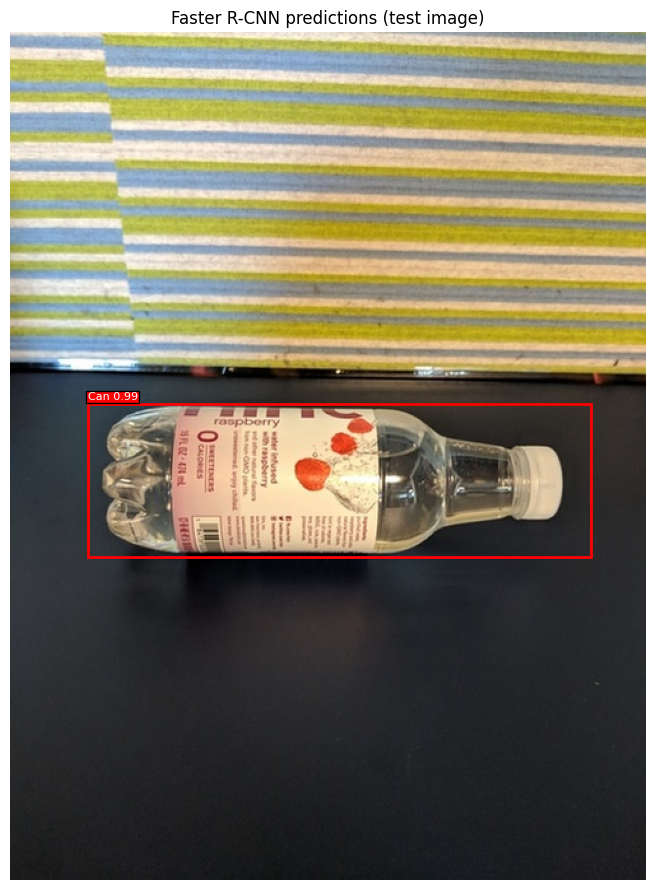

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
model.eval()
img_t, target = DetDataset(test_ids, False)[0]
with torch.no_grad():
    out = model([img_t.to(device)])[0]
keep = out["scores"].cpu().numpy() >= SCORE_THR
boxes = out["boxes"].cpu().numpy()[keep]
labels = out["labels"].cpu().numpy()[keep]
scores = out["scores"].cpu().numpy()[keep]
fig, ax = plt.subplots(1, figsize=(7, 9))
ax.imshow(img_t.permute(1, 2, 0)); ax.axis("off")
for b, l, s in zip(boxes, labels, scores):
    ax.add_patch(patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], fill=False, edgecolor="red", linewidth=2))
    ax.text(b[0], b[1]-3, f"{LABEL2NAME.get(int(l),'?')} {s:.2f}", color="white",
            bbox=dict(facecolor="red", pad=1), fontsize=8)
ax.set_title("Faster R-CNN predictions (test image)")
plt.tight_layout(); plt.show()

## Observations
* Starting from COCO-pretrained Faster R-CNN, the model adapts to the 4 product classes
  quickly because the backbone already detects generic bottle/box/can shapes; 10 epochs on
  100 images is enough to reach high precision/recall at IoU 0.5.
* Precision is generally high (few false positives thanks to the 0.5 score threshold),
  while recall is limited mainly by small or occluded objects and by visually similar
  classes such as `Milk Bottle` vs `Water Bottle`.
* Using a score threshold of 0.5 gives a balanced precision/recall operating point; a lower
  threshold would raise recall at the cost of more false positives.